# Spurious-Signal Study

This notebook measures fitted signal yields when background-only pseudo-datasets are analyzed with a signal-plus-background model. It uses the high-mass diphoton example, multiple background truth models, and Gaussian signal hypotheses spanning the mass range considered in the paper.

## Roadmap

1. Load the data, construct and fit candidate background truth models.
2. Define signal mass and width points, toy counts, and restart settings.
3. Run or submit the pseudo-experiments and cache their fit results.
4. Combine the results, perform AIC model selection where requested, and plot the fitted spurious signal.

The study keeps the null and signal-plus-background fits on the same generated toy so that fitted signal yields are directly comparable.

In [1]:
# Imports
import ROOT
import array

from tools import scale_out as so

from emm import data as dat
from emm import fitting
from emm import models
from emm import bias

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT.gErrorIgnoreLevel = ROOT.kWarning

fit_options = [
    ROOT.RooFit.PrintLevel(0),
]


Welcome to JupyROOT 6.30/04


In [2]:
# Load data
x = ROOT.RooRealVar("x", "Diphoton Mass [GeV]", 500, 10_000)
data_tree = dat.get_diphoton_data(tree=True)
diphoton_data = ROOT.RooDataSet("mgg", "mgg", ROOT.RooArgSet(x), ROOT.RooFit.Import(data_tree))
n = diphoton_data.numEntries()
data_mean = diphoton_data.mean(x)
print(f"Data mean: {data_mean}")

Data mean: 676.7652379849756


In [3]:
# Set up models
toy_models = [
    models.f1(x),
    models.f2(x),
    models.f3(x),
    models.f4(x),
]

model_primitives = [
    models.ModelPrimitive(
        models.ExponentialMixtureModel,
        k, data_mean=data_mean,
        name=f"ExponentialMixture-{k}"
    ) for k in range(2, 5)
]

# Fit toy models to data
for toy_model in toy_models:
    print(f"Fitting toy model: {toy_model.name}")
    toy_model.pdf.fitTo(diphoton_data)


Fitting toy model: f_1
Fitting toy model: f_2
Fitting toy model: f_3
Fitting toy model: f_4
[#1] INFO:NumericIntegration -- RooRealIntegral::init(f_1_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
Minuit2Minimizer: Minimize with max-calls 1000 convergence for edm < 1 strategy 1
Minuit2Minimizer : Valid minimum - status = 1
FVAL  = 31033.2097955985919
Edm   = 0.000159485240499530157
Nfcn  = 27
p1	  = 5.71808	 +/-  0.898473	(limited)
p2	  = -0.778647	 +/-  0.0667606	(limited)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:NumericIntegration -- RooRealIntegral::init(f_2_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
Minuit2Minimizer: Minimize with max-calls 1000 convergence for edm < 1 strateg

Warning in <Minuit2>: MnPosDef Matrix forced pos-def by adding to diagonal 0.00459152
Warning in <Minuit2>: Minuit2Minimizer::Minimize Covar was made pos def


In [4]:
# Configuration
signal_points = [
    (500, 25),
    (600, 30),
    (800, 35),
    (1000, 40),
    (1200, 45),
    (1400, 50),
    (1600, 55),
    (1800, 60),
    (2000, 65),
]

n_restarts = 50
n_retries = 10

# Default
n_seeds = 100
n_toys_per_seed = 10

# Test overrides
# n_seeds = 2
# n_toys_per_seed = 1

# Generate seeds
default_seed = 123456
np.random.seed(default_seed)
seeds = np.random.randint(0, 10000, size=n_seeds)
print(f"Will be submitting {n_seeds * len(toy_models)} tasks, with {n_toys_per_seed} toys fitting {len(model_primitives)} models and {len(signal_points)} signal points.")

Will be submitting 400 tasks, with 10 toys fitting 3 models and 9 signal points.


## Pseudo-Experiment Execution

Each task covers one random seed and one calibrated background truth model. It generates the configured number of toys, fits every candidate background, and then performs background-only and signal-plus-background fits at every signal point. Results are cached per truth model and seed, so `remake` controls whether existing study outputs are replaced.

In [19]:
# Run jobs
import os

remake=True

tasks = []
for seed in seeds:
    for toy_model in toy_models:
        output = bias.get_spurious_signal_fits_cache_path(
            toy_model, seed, n_toys_per_seed)
        if os.path.exists(output):
            if remake:
                print(f"Output {output} already exists, but remake=True, so overwriting.")
                os.remove(output)
            else:
            # print(f"Output {output} already exists, skipping.")
                continue

        _model_primitives = model_primitives.copy()
        _model_primitives.append(
            models.ModelPrimitive(type(toy_model))
        )
        tasks.append(
            so.Task(
                bias.run_spurious_signal_fits,
                x, toy_model, _model_primitives,
                seed, n_toys_per_seed,
                n, signal_points,
                n_restarts, n_retries,
                fit_options=fit_options,
                print_level=1
            )
        )

_ = so.run_tasks(
    tasks,
    use_condor=True,
    condor_job_name="spurious_signal",
    env_wrapper=so.run_in_mamba,
    clear_logs=True
)

Submitting 400 tasks to condor with job name 'spurious_signal'


In [7]:
# Load results
results = []
for toy_model in toy_models:
    results.extend(
        bias.load_spurious_signal_fit_results(
            toy_model, seeds, n_toys_per_seed
        )
    )
results_df = pd.DataFrame(results)

## Model Selection and Summary

The aggregation step keeps the fixed analytic backgrounds and selects one exponential-mixture order per toy and signal hypothesis using AIC or BIC. This ensures that the summary compares like-for-like fitted signal yields while accounting for the mixture order selected by the likelihood.

In [9]:
# Do model selection
seeds = results_df["seed"].unique()

group_cols = ["toy_model_name","signal_mean", "signal_width", "seed", "toy_index"]

is_exp = results_df["bkg_model_name"].str.contains("ExponentialMixture")
exp_df = results_df[is_exp].copy()
non_exp_df = results_df[~is_exp].copy()

# Sanity check: every (signal point, c, seed, toy) group must have at least one
# ExponentialMixture fit, matching the per-group ValueError in the original loop.
all_groups = set(map(tuple, results_df[group_cols].drop_duplicates().itertuples(index=False, name=None)))
exp_groups = set(map(tuple, exp_df[group_cols].drop_duplicates().itertuples(index=False, name=None)))
missing_groups = all_groups - exp_groups
if missing_groups:
    raise ValueError(f"No ExponentialMixture model found for groups: {missing_groups}")

exp_df["k"] = exp_df["bkg_model_name"].str.split("-").str[-1].astype(int)
exp_df["n_params"] = 2 * exp_df["k"] - 1
exp_df["aic"] = 2 * exp_df["n_params"] + 2 * exp_df["bkg_only_nll"]
exp_df["bic"] = np.log(n) * exp_df["n_params"] + 2 * exp_df["bkg_only_nll"]

best_aic_df = exp_df.loc[exp_df.groupby(group_cols)["aic"].idxmin()].copy()
best_aic_df["bkg_model_name"] = "ExponentialMixture (AIC)"

best_bic_df = exp_df.loc[exp_df.groupby(group_cols)["bic"].idxmin()].copy()
best_bic_df["bkg_model_name"] = "ExponentialMixture (BIC)"

df = pd.concat([non_exp_df, best_aic_df, best_bic_df], ignore_index=True)

In [12]:
# Report how often each ExponentialMixture order k was selected by AIC, broken down by injection strength c
aic_counts = best_aic_df.groupby(["toy_model_name", "k"]).size().unstack(fill_value=0)
aic_fractions = aic_counts.div(aic_counts.sum(axis=1), axis=0)

print("AIC selection counts by injection strength (c) and k:")
print(aic_counts)
print("\nAIC selection fractions by injection strength (c) and k:")
print(aic_fractions)

AIC selection counts by injection strength (c) and k:
k                  2     3   4
toy_model_name                
f_1             4707  4023  90
f_2             5805  2979  36
f_3             4194  4554  72
f_4             5904  2889  27

AIC selection fractions by injection strength (c) and k:
k                      2         3         4
toy_model_name                              
f_1             0.533673  0.456122  0.010204
f_2             0.658163  0.337755  0.004082
f_3             0.475510  0.516327  0.008163
f_4             0.669388  0.327551  0.003061


/tmp/ipykernel_810870/1779198386.py:21: RuntimeWarning: invalid value encountered in sqrt
  metric = lambda row: np.sign(row["n_sig"])*np.sqrt(2*(-row["alt_nll"] + row["bkg_only_nll"]))
/tmp/ipykernel_810870/1779198386.py:21: RuntimeWarning: invalid value encountered in sqrt
  metric = lambda row: np.sign(row["n_sig"])*np.sqrt(2*(-row["alt_nll"] + row["bkg_only_nll"]))
/tmp/ipykernel_810870/1779198386.py:21: RuntimeWarning: invalid value encountered in sqrt
  metric = lambda row: np.sign(row["n_sig"])*np.sqrt(2*(-row["alt_nll"] + row["bkg_only_nll"]))
/tmp/ipykernel_810870/1779198386.py:21: RuntimeWarning: invalid value encountered in sqrt
  metric = lambda row: np.sign(row["n_sig"])*np.sqrt(2*(-row["alt_nll"] + row["bkg_only_nll"]))
/tmp/ipykernel_810870/1779198386.py:21: RuntimeWarning: invalid value encountered in sqrt
  metric = lambda row: np.sign(row["n_sig"])*np.sqrt(2*(-row["alt_nll"] + row["bkg_only_nll"]))
/tmp/ipykernel_810870/1779198386.py:21: RuntimeWarning: invalid value 

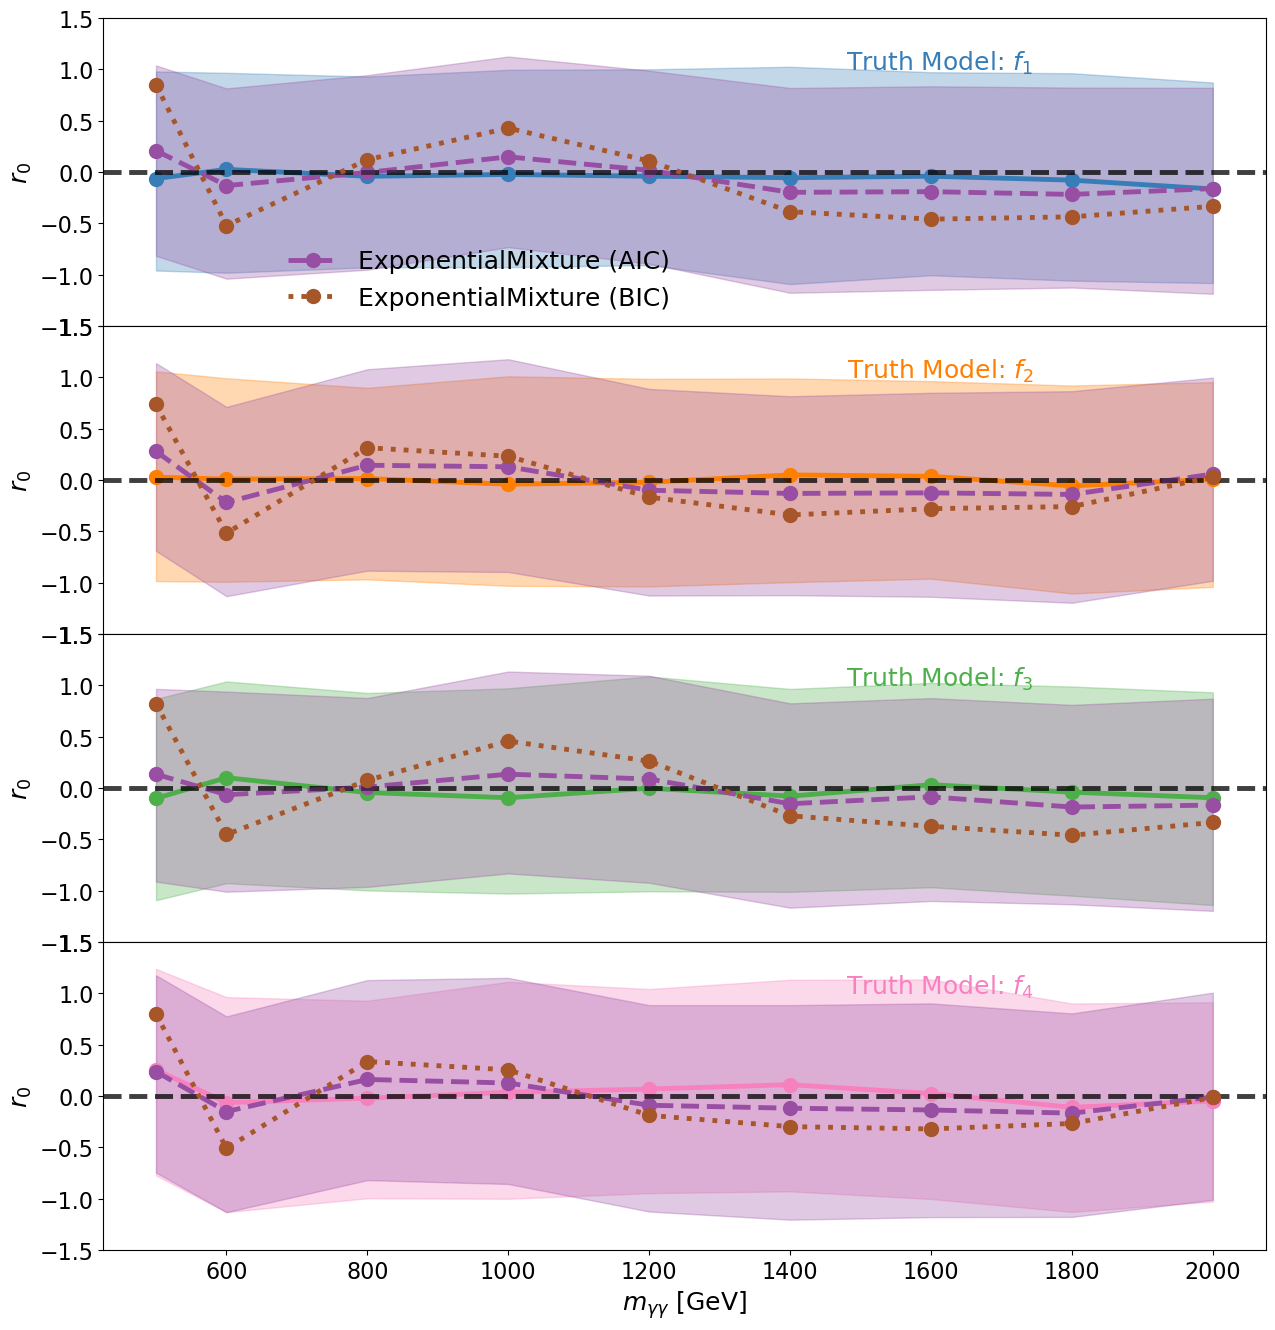

In [15]:
# Plot results
import matplotlib.pyplot as plt

toy_model_names = [m.name for m in toy_models]

fontsize = 18
labelsize = 16
linewidth = 3.5
markersize = 10

colors = {
    "f_1": '#377eb8',
    "f_2": '#ff7f00',
    "f_3": '#4daf4a',
    "f_4": '#f781bf',
    "ExponentialMixture (AIC)": '#984ea3',
    "ExponentialMixture (BIC)": '#a65628',
}
line_styles = ['solid', 'dashed', 'dotted']

metric = lambda row: np.sign(row["n_sig"])*np.sqrt(2*(-row["alt_nll"] + row["bkg_only_nll"]))

fig, axs = plt.subplots(
    len(toy_model_names), 1,
    figsize=(15, 4 * len(toy_model_names)),
    sharex=True,
    gridspec_kw={"hspace": 0}
)
for i, toy_model_name in enumerate(toy_model_names):

    if len(toy_model_names) == 1:
        ax = axs
    else:
        ax = axs[i]

    ax.text(
            0.8,
            0.9,
            f"Truth Model: ${toy_model_name}$",
            transform=ax.transAxes,
            fontsize=fontsize,
            verticalalignment='top',
            horizontalalignment='right',
            color=colors[toy_model_name]
        )

    # toy_model_name = toy_model.name
    toy_model_df = df[df["toy_model_name"] == toy_model_name]

    # Signal points
    models_to_plot = {
        toy_model_name: (toy_model_name, colors[toy_model_name], line_styles[0]),
        "ExponentialMixture (AIC)": ("ExponentialMixture (AIC)", colors["ExponentialMixture (AIC)"], line_styles[1]),
        "ExponentialMixture (BIC)": ("ExponentialMixture (BIC)", colors["ExponentialMixture (BIC)"], line_styles[2]),
    }

    y_err_true = None

    for bkg_model_name, (label, color, line_style) in models_to_plot.items():
        model_df = toy_model_df[toy_model_df["bkg_model_name"] == bkg_model_name]
        ms = []
        ys = []
        y_lows = []
        y_highs = []
        for signal_point in signal_points:
            signal_point_df = model_df[
                (model_df["signal_mean"] == signal_point[0]) &
                (model_df["signal_width"] == signal_point[1])
            ]
            
            # A handful of toys have failed sb fits (sb_nll > b_nll), which makes the
            # sqrt argument negative and produces a NaN. np.percentile propagates a single
            # NaN to every requested percentile, so use np.nanpercentile to ignore them.
            y = signal_point_df.apply(metric, axis=1).values
            y_med, y_low, y_high = np.nanpercentile(y, [50, 16, 84])
            ms.append(signal_point[0])
            ys.append(y_med)
            y_lows.append(y_low)
            y_highs.append(y_high)


        if "_" in label:
            label = f"${label}$"
        if bkg_model_name == toy_model_name:
            # label = f"{label} (True Model)"
            label = None

        ax.plot(ms, ys, label=label, marker="o", color=color, linestyle=line_style, linewidth=linewidth, markersize=markersize)
        # print(f"{toy_model_name} - {bkg_model_name}:")
        # print(f"  Signal points: {ms}")
        # print(f"  Spurious signal (S): {ys}")
        if bkg_model_name == "ExponentialMixture (BIC)":
            continue
        ax.fill_between(ms, y_lows, y_highs, alpha=0.3, color=color)
        ax.axhline(0, color="black", linestyle="--", alpha=0.5, linewidth=linewidth)

    if i == 0:
        ax.legend(framealpha=0.3, loc=(0.15, 0.02), fontsize=fontsize, frameon=False)
    ax.set_xlabel("$m_{\\gamma\\gamma}$ [GeV]", fontsize=fontsize)
    ax.tick_params(axis='x', labelsize=labelsize)
    # ax.set_ylabel("Spurious Signal Yield")
    ax.set_ylabel("$r_0$", fontsize=fontsize)
    ax.tick_params(axis='y', labelsize=labelsize)
    ax.set_ylim(-1.5, 1.5)
    
